In [149]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import pandas as pd
import aerosandbox as asb
import pyfar as pf
from FastBEMT.JobParameters import AerodynamicParameters, AcousticParameters
from FastBEMT.Propeller import Propeller
from FastBEMT.BPM import BPM

with open("../Datasets/Propellers/10x7E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

aerodynamic_params = AerodynamicParameters(
    prop_radius=blade_dict['tip_radius'],
    hub_radius=blade_dict['hub_radius'],
    n_blades=blade_dict['n_blades'],
    rpm=5000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
)

acoustic_params = AcousticParameters(
    aero_params=aerodynamic_params,
    p_ref=2e-5, revolutions=100, num_obs_times_per_rev=1000
)

In [150]:
propeller = Propeller(
    propeller_geometry=blade_dict,
    aero_params=aerodynamic_params,
    acoustic_params=acoustic_params
)
v_inf = 0
propeller.run_bemt(v_inf=v_inf)

In [151]:
r_observer = np.array([[0.1, 1.8, 0], [0.1, 0, 1.8]])
propeller.run_compact_f1a(observer_positions=r_observer, use_gpu=True)

In [152]:
third_octave_freqs = pf.dsp.filter.fractional_octave_frequencies(num_fractions=3, frequency_range=(20,20000))[1]

In [153]:
bpm = BPM(propeller=propeller, frequencies=third_octave_freqs)
bpm.run_bpm(lt=1e6)

In [154]:
t = propeller.t[:, 0]
p_tone = propeller.p_tot[:, 0]

fs = 1 / (t[1] - t[0])
signal = pf.Signal(p_tone, fs, fft_norm='rms')
F1A_frequencies = signal.frequencies
F1A_spl = pf.dsp.decibel(signal, domain='freq', log_reference=propeller.acoustic_params.p_ref).squeeze()

In [155]:
f1a_spl_3oct = []
n_o = propeller.spl.shape[1]
for fc in third_octave_freqs:
    f_low, f_high = fc / (2 ** (1 / 6)), fc * (2 ** (1 / 6))
    mask = (propeller.freq[:, 0] >= f_low) & (propeller.freq[:, 0] < f_high)
    if np.any(mask):
        p_band = np.sum(10 ** (propeller.spl[mask, :] / 10), axis=0)
        f1a_spl_3oct.append(10 * np.log10(p_band))
    else:
        f1a_spl_3oct.append(np.full(n_o, -np.inf))
f1a_spl_3oct = np.array(f1a_spl_3oct)

L_total = 10 * np.log10(
    10 ** (f1a_spl_3oct / 10) # ok
    + 10 ** (bpm.spl_lbl / 10) # ok
    + 10 ** (bpm.spl_tbl / 10)
    + 10 ** (bpm.spl_teb / 10)
    + 10 ** (bpm.spl_ti / 10)
    + 10 ** (bpm.spl_tip / 10) # ok
)

In [156]:
def load_data(filepath):
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    t = data['sound']['channels']['1']['time']
    p = data['sound']['channels']['1']['pressure']
    fs = 1.0 / np.mean(np.diff(t))
    return t, p, fs

# 1. Load data
t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x7e_2024-11-28-13-21-17_RPM_5000.pkl')
# t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x7e_2024-11-28-13-14-55_RPM_7000.pkl')
# t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x5e_2024-11-28-11-23-21_RPM_7000.pkl')
signal = pf.Signal(p_total, fs_total, fft_norm='rms')
meas_frequencies = signal.frequencies
meas_spl = pf.dsp.decibel(signal, domain='freq', log_reference=propeller.acoustic_params.p_ref).squeeze()

In [157]:
blade_passing_freq = 1 / acoustic_params.blade_passing_period

In [158]:
exp_spl_3oct = []
for fc in third_octave_freqs:
    f_low, f_high = fc / (2**(1/6)), fc * (2**(1/6))
    mask = (meas_frequencies >= f_low) & (meas_frequencies < f_high)
    if np.any(mask):
        P_band = np.sum(10**(meas_spl[mask] / 10))
        exp_spl_3oct.append(10 * np.log10(P_band))
    else:
        exp_spl_3oct.append(-np.inf)

exp_spl_3oct = np.array(exp_spl_3oct)

In [159]:
def get_a_weighting(f):
    """Calculate A-weighting offset in dB for a given frequency f."""
    ra = lambda f: (12194**2 * f**4) / (
        (f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2)) * (f**2 + 12194**2)
    )
    return 20 * np.log10(ra(f)) - 20 * np.log10(ra(1000))

In [160]:
def calc_oaspl(spl_array, freqs, weighted=False):
    """Calculates OSPL or A-weighted OASPL."""
    valid_mask = np.isfinite(spl_array)
    spl = spl_array[valid_mask]
    f = freqs[valid_mask]
    
    if len(spl) == 0: return 0
    
    if weighted:
        a_offsets = get_a_weighting(f)
        spl = spl + a_offsets
        
    return 10 * np.log10(np.sum(10**(spl[f >= 0.9*blade_passing_freq] / 10)))

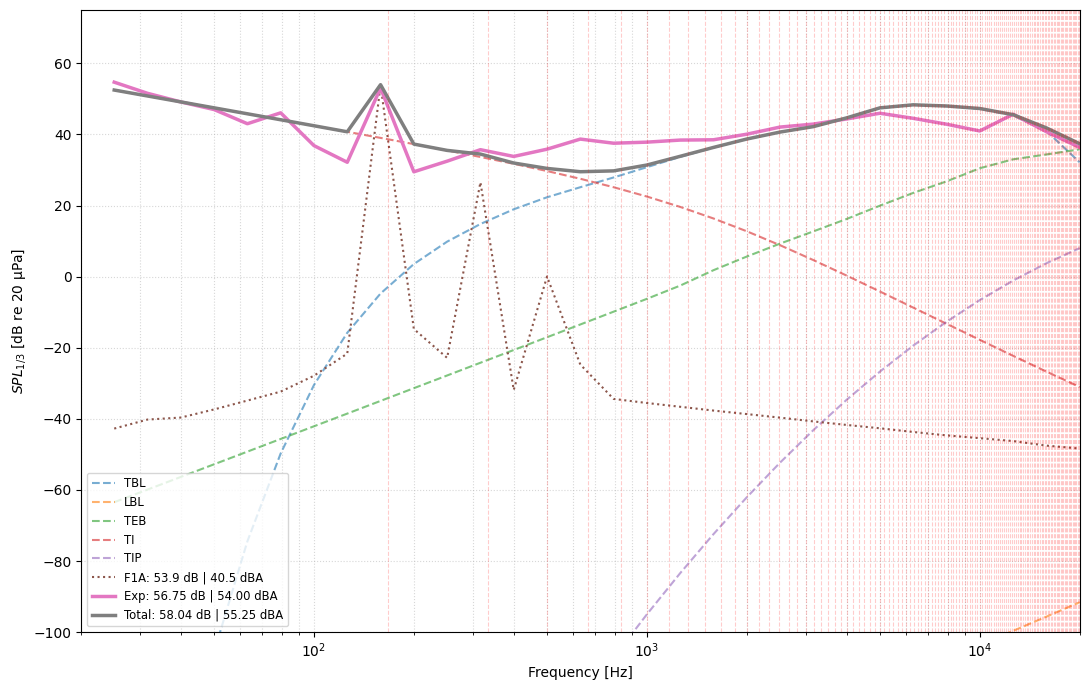

In [161]:
# Values for labels
ospl_f1a = calc_oaspl(f1a_spl_3oct[:, 0], third_octave_freqs, weighted=False)
oaspl_f1a = calc_oaspl(f1a_spl_3oct[:, 0], third_octave_freqs, weighted=True)

ospl_exp = calc_oaspl(exp_spl_3oct, third_octave_freqs, weighted=False)
oaspl_exp = calc_oaspl(exp_spl_3oct, third_octave_freqs, weighted=True)

ospl_tot = calc_oaspl(L_total[:, 0], third_octave_freqs, weighted=False)
oaspl_tot = calc_oaspl(L_total[:, 0], third_octave_freqs, weighted=True)

plt.figure(figsize=(11, 7))

# Components (keeping these simpler to avoid legend clutter)
plt.semilogx(third_octave_freqs, bpm.spl_tbl[:, 0], '--', alpha=0.6, label='TBL')
plt.semilogx(third_octave_freqs, bpm.spl_lbl[:, 0], '--', alpha=0.6, label='LBL')
plt.semilogx(third_octave_freqs, bpm.spl_teb[:, 0], '--', alpha=0.6, label='TEB')
plt.semilogx(third_octave_freqs, bpm.spl_ti[:, 0], '--', alpha=0.6, label='TI')
plt.semilogx(third_octave_freqs, bpm.spl_tip[:, 0], '--', alpha=0.6, label='TIP')
# plt.semilogx(third_octave_freqs, bpm.SPL_BWI, '--', alpha=0.6, label='BWI')
plt.semilogx(third_octave_freqs, f1a_spl_3oct[:, 0], ':', label=f'F1A: {ospl_f1a:.1f} dB | {oaspl_f1a:.1f} dBA')

# Main Comparison Lines
plt.semilogx(third_octave_freqs, exp_spl_3oct, '-', linewidth=2.5, 
             label=f'Exp: {ospl_exp:.2f} dB | {oaspl_exp:.2f} dBA')
plt.semilogx(third_octave_freqs, L_total[:, 0], '-', linewidth=2.5, 
             label=f'Total: {ospl_tot:.2f} dB | {oaspl_tot:.2f} dBA')

max_f = np.max(propeller.freq)
harmonic_freqs = np.arange(blade_passing_freq, max_f, blade_passing_freq)
for bpf in harmonic_freqs:
    plt.axvline(bpf, color='red', linestyle='--', linewidth=0.8, alpha=0.2)

plt.xlabel('Frequency [Hz]')
plt.ylabel('$SPL_{1/3}$ [dB re 20 µPa]')
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.legend(loc='lower left', fontsize='small', frameon=True)
plt.xlim(20, 20000)
plt.ylim(-100, 75)
plt.tight_layout()
plt.show()